In [1]:
!pip install openpyxl


[notice] A new release of pip is available: 25.2 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


### EDA (Exploratory Data Analysis)

The dataset that we going to use have the historical behavior about the eletric power generation levels (measured in megawatts/hora, or MWh) to different generation sources (oil, hydroelectric, solar, thermal,coal,nuclear,etc..) for teh period included between 2001 and 2025 year.

This data is available in the *U.S. Energy Information Administration* (EIA) website.

To download the data follow the next steps:
1. Go to the official website: https://www.eia.gov/electricity/data.php
2. Go to the section "Generation and thermal output"
3. Download the excel file named "Monthly (back to 2001)"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
route = "./datasets/generation_monthly.xlsx"

#File Header
#sheets 0,1,2,3,4:header in the row 0 
#sheets 5:18 header in the row 4

SHEET_NAMES = list(range(19)) #spreadsheets to read (0 to 18)
SKIP_ROWS = [None] * 5 + [4] * 14 # number of rows to jump in the moment of the sheet lecture

#Read each sheet
DF = [None]*len(SHEET_NAMES)
for i,sheet in enumerate(SHEET_NAMES):
    DF[i] = pd.read_excel(route,sheet_name=sheet,skiprows=SKIP_ROWS[i])

#print headers
for df in DF:
    print(df.columns)

Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (Megawatthours)'],
      dtype='object')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (Megawatthours)'],
      dtype='object')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (Megawatthours)'],
      dtype='object')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (Megawatthours)'],
      dtype='object')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (Megawatthours)'],
      dtype='object')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (Megawatthours)'],
      dtype='object')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (Megawatthours)'],
      dtype='object')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (

C:\Users\sgfar\AppData\Local\Programs\Python\Python313\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [4]:
#redifine the columns names
NAMES = ['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
        'GENERATION (MWh)']

#Read each sheet
DF = [None]*len(SHEET_NAMES)
for i,sheet in enumerate(SHEET_NAMES):
    DF[i] = pd.read_excel(route,sheet_name=sheet,skiprows=SKIP_ROWS[i],names=NAMES)

#print headers
for df in DF:
    print(df.columns)


Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (MWh)'],
      dtype='object')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (MWh)'],
      dtype='object')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (MWh)'],
      dtype='object')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (MWh)'],
      dtype='object')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (MWh)'],
      dtype='object')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (MWh)'],
      dtype='object')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (MWh)'],
      dtype='object')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (MWh)'],
      dtype='object')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE O

C:\Users\sgfar\AppData\Local\Programs\Python\Python313\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [5]:
#our original dataset is splitted by 19 spreadsheets so  we need concat all the spreadsheet in one dataframe
df = pd.concat(DF,ignore_index=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 586147 entries, 0 to 586146
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   YEAR              586147 non-null  int64  
 1   MONTH             586147 non-null  int64  
 2   STATE             586147 non-null  object 
 3   TYPE OF PRODUCER  586147 non-null  object 
 4   ENERGY SOURCE     586147 non-null  object 
 5   GENERATION (MWh)  586147 non-null  float64
dtypes: float64(1), int64(2), object(3)
memory usage: 26.8+ MB


In [6]:
df

,YEAR,MONTH,STATE,TYPE OF PRODUCER,ENERGY SOURCE,GENERATION (MWh)
0,2001,1,AK,Total Electric Power Industry,Coal,46903.0
1,2001,1,AK,Total Electric Power Industry,Petroleum,71085.0
2,2001,1,AK,Total Electric Power Industry,Natural Gas,367521.0
3,2001,1,AK,Total Electric Power Industry,Hydroelectric Conventional,104549.0
4,2001,1,AK,Total Electric Power Industry,Wind,87.0
...,...,...,...,...,...,...
586142,2025,11,WY,"Electric Generators, Electric Utilities",Coal,2279287.0
586143,2025,11,WY,"Electric Generators, Electric Utilities",Hydroelectric Conventional,87061.0
586144,2025,11,WY,"Electric Generators, Electric Utilities",Natural Gas,399701.0
586145,2025,11,WY,"Electric Generators, Electric Utilities",Petroleum,3901.0


#### Exploratory Analysis Approach

First we need define our objetive:
 
 1-In this project we'll focus on the historical behavior of the energy source, but there are other focuses like historical behavior of states or type of producer.


#### Pre Processing and Series Time Cleaning

Convert the Dataframe to Time Series

In [7]:
df['DATE'] = pd.to_datetime(df[['YEAR','MONTH']].assign(DAY=1))
df

,YEAR,MONTH,STATE,TYPE OF PRODUCER,ENERGY SOURCE,GENERATION (MWh),DATE
0,2001,1,AK,Total Electric Power Industry,Coal,46903.0,2001-01-01
1,2001,1,AK,Total Electric Power Industry,Petroleum,71085.0,2001-01-01
2,2001,1,AK,Total Electric Power Industry,Natural Gas,367521.0,2001-01-01
3,2001,1,AK,Total Electric Power Industry,Hydroelectric Conventional,104549.0,2001-01-01
4,2001,1,AK,Total Electric Power Industry,Wind,87.0,2001-01-01
...,...,...,...,...,...,...,...
586142,2025,11,WY,"Electric Generators, Electric Utilities",Coal,2279287.0,2025-11-01
586143,2025,11,WY,"Electric Generators, Electric Utilities",Hydroelectric Conventional,87061.0,2025-11-01
586144,2025,11,WY,"Electric Generators, Electric Utilities",Natural Gas,399701.0,2025-11-01
586145,2025,11,WY,"Electric Generators, Electric Utilities",Petroleum,3901.0,2025-11-01


In [8]:
df.set_index('DATE',inplace=True)
df.drop(labels=['YEAR','MONTH'],axis=1,inplace=True)
df

,STATE,TYPE OF PRODUCER,ENERGY SOURCE,GENERATION (MWh)
DATE,,,,
2001-01-01,AK,Total Electric Power Industry,Coal,46903.0
2001-01-01,AK,Total Electric Power Industry,Petroleum,71085.0
2001-01-01,AK,Total Electric Power Industry,Natural Gas,367521.0
2001-01-01,AK,Total Electric Power Industry,Hydroelectric Conventional,104549.0
2001-01-01,AK,Total Electric Power Industry,Wind,87.0
...,...,...,...,...
2025-11-01,WY,"Electric Generators, Electric Utilities",Coal,2279287.0
2025-11-01,WY,"Electric Generators, Electric Utilities",Hydroelectric Conventional,87061.0
2025-11-01,WY,"Electric Generators, Electric Utilities",Natural Gas,399701.0


In [9]:
#Here also we'll drop the TYPE OF PRODUCER AND STATE columns because our  time series  only focused in the energy source and generation data but 
# also you may take other columns to get the analysis
df.drop(columns=['STATE','TYPE OF PRODUCER'],inplace=True)
df

,ENERGY SOURCE,GENERATION (MWh)
DATE,,
2001-01-01,Coal,46903.0
2001-01-01,Petroleum,71085.0
2001-01-01,Natural Gas,367521.0
2001-01-01,Hydroelectric Conventional,104549.0
2001-01-01,Wind,87.0
...,...,...
2025-11-01,Coal,2279287.0
2025-11-01,Hydroelectric Conventional,87061.0
2025-11-01,Natural Gas,399701.0


In [10]:
df['ENERGY SOURCE'].value_counts()

ENERGY SOURCE
Total                             85565
Natural Gas                       77577
Petroleum                         73480
Coal                              54740
Other Biomass                     54341
Hydroelectric Conventional        45397
Other                             43694
Wood and Wood Derived Fuels       35788
Wind                              31093
Solar Thermal and Photovoltaic    27529
Other Gases                       20821
Nuclear                           19257
Pumped Storage                    11835
Geothermal                         5030
Name: count, dtype: int64

These are energy source that we have and each one will be a Time Serie

For example, "coal" energy source we will have historical records from 2001-01-01 to 2025-11-01,"Petroleum" will have the same historical records,ect...

In [11]:
#Group by date, energy source and the sum outcome
groups = df.groupby(['ENERGY SOURCE',df.index]).sum()
groups

GENERATION (MWh)
ENERGY SOURCE               DATE                        
Coal                        2001-01-01       709148444.0
                            2001-02-01       598941934.0
                            2001-03-01       621076042.0
                            2001-04-01       562682612.0
                            2001-05-01       606371658.0
...                                                  ...
Wood and Wood Derived Fuels 2025-07-01        11607868.0
                            2025-08-01        11341182.0
                            2025-09-01        10903105.0
                            2025-10-01         9850670.0
                            2025-11-01        10325175.0

[4186 rows x 1 columns]

In [12]:
names_series = groups.index.get_level_values("ENERGY SOURCE").unique()

names_series

Index(['Coal', 'Geothermal', 'Hydroelectric Conventional', 'Natural Gas',
       'Nuclear', 'Other', 'Other Biomass', 'Other Gases', 'Petroleum',
       'Pumped Storage', 'Solar Thermal and Photovoltaic', 'Total', 'Wind',
       'Wood and Wood Derived Fuels'],
      dtype='object', name='ENERGY SOURCE')

In [13]:
series = {}

for name in names_series:
    if name != "Total":
        serie = groups.xs(name,level="ENERGY SOURCE").sort_index()
        series[name] = serie

series["Coal"]

,GENERATION (MWh)
DATE,
2001-01-01,709148444.0
2001-02-01,598941934.0
2001-03-01,621076042.0
2001-04-01,562682612.0
2001-05-01,606371658.0
...,...
2025-07-01,321040962.0
2025-08-01,278912131.0
2025-09-01,233706467.0


In [14]:
for key, value in series.items():
    print(f'No. records serie {key}: {len(series[key])}')
    print(f'Date start-final serie {key}: {series[key].index.min()}-{series[key].index.max()}' )
    print('-'*100)

No. records serie Coal: 299
Date start-final serie Coal: 2001-01-01 00:00:00-2025-11-01 00:00:00
----------------------------------------------------------------------------------------------------
No. records serie Geothermal: 299
Date start-final serie Geothermal: 2001-01-01 00:00:00-2025-11-01 00:00:00
----------------------------------------------------------------------------------------------------
No. records serie Hydroelectric Conventional: 299
Date start-final serie Hydroelectric Conventional: 2001-01-01 00:00:00-2025-11-01 00:00:00
----------------------------------------------------------------------------------------------------
No. records serie Natural Gas: 299
Date start-final serie Natural Gas: 2001-01-01 00:00:00-2025-11-01 00:00:00
----------------------------------------------------------------------------------------------------
No. records serie Nuclear: 299
Date start-final serie Nuclear: 2001-01-01 00:00:00-2025-11-01 00:00:00
-----------------------------------

How we can see all our series have the same number of records with a total of 299 months starting in 2001-01-01 to 2025-11-01

In [15]:
#Cheack if we have a null values
for key,value in series.items():
    nNull = series[key].isna().sum()
    print(f"Number of null values: {key}:{nNull}")

Number of null values: Coal:GENERATION (MWh)    0
dtype: int64
Number of null values: Geothermal:GENERATION (MWh)    0
dtype: int64
Number of null values: Hydroelectric Conventional:GENERATION (MWh)    0
dtype: int64
Number of null values: Natural Gas:GENERATION (MWh)    0
dtype: int64
Number of null values: Nuclear:GENERATION (MWh)    0
dtype: int64
Number of null values: Other:GENERATION (MWh)    0
dtype: int64
Number of null values: Other Biomass:GENERATION (MWh)    0
dtype: int64
Number of null values: Other Gases:GENERATION (MWh)    0
dtype: int64
Number of null values: Petroleum:GENERATION (MWh)    0
dtype: int64
Number of null values: Pumped Storage:GENERATION (MWh)    0
dtype: int64
Number of null values: Solar Thermal and Photovoltaic:GENERATION (MWh)    0
dtype: int64
Number of null values: Wind:GENERATION (MWh)    0
dtype: int64
Number of null values: Wood and Wood Derived Fuels:GENERATION (MWh)    0
dtype: int64


In [16]:
for key, value in series.items():
    
    serie = series[key]
    
    rango_completo = pd.date_range(start=serie.index.min(), end=serie.index.max(), freq='MS') # MS: month start
    
    serie_reindex = serie.reindex(rango_completo)
    
    nNull = serie_reindex.isna().sum()
    print(f'No. missing timestamps serie {key}: {nNull}')

No. missing timestamps serie Coal: GENERATION (MWh)    0
dtype: int64
No. missing timestamps serie Geothermal: GENERATION (MWh)    0
dtype: int64
No. missing timestamps serie Hydroelectric Conventional: GENERATION (MWh)    0
dtype: int64
No. missing timestamps serie Natural Gas: GENERATION (MWh)    0
dtype: int64
No. missing timestamps serie Nuclear: GENERATION (MWh)    0
dtype: int64
No. missing timestamps serie Other: GENERATION (MWh)    0
dtype: int64
No. missing timestamps serie Other Biomass: GENERATION (MWh)    0
dtype: int64
No. missing timestamps serie Other Gases: GENERATION (MWh)    0
dtype: int64
No. missing timestamps serie Petroleum: GENERATION (MWh)    0
dtype: int64
No. missing timestamps serie Pumped Storage: GENERATION (MWh)    0
dtype: int64
No. missing timestamps serie Solar Thermal and Photovoltaic: GENERATION (MWh)    0
dtype: int64
No. missing timestamps serie Wind: GENERATION (MWh)    0
dtype: int64
No. missing timestamps serie Wood and Wood Derived Fuels: GENERA

In [17]:
SERIES = pd.concat([series[key] for key in sorted(series)], axis=1) # Usar sorted para escoger los keys en orden alfabético
SERIES.columns = list(sorted(series.keys())) # Nuevamente sorted para que las columnas coincidan con la concatenación anterior
SERIES

,Coal,Geothermal,Hydroelectric Conventional,Natural Gas,Nuclear,Other,Other Biomass,Other Gases,Petroleum,Pumped Storage,Solar Thermal and Photovoltaic,Wind,Wood and Wood Derived Fuels
DATE,,,,,,,,,,,,,
2001-01-01,709148444.0,4917300.0,75408194.0,169554652.0,274828308.0,3966680.0,4834584.0,2873768.0,72447372.0,-2354504.0,26000.0,1557000.0,12764848.0
2001-02-01,598941934.0,4292176.0,69891562.0,151867704.0,245089628.0,3487797.0,4385324.0,2702636.0,41366012.0,-2827824.0,50272.0,1724968.0,10788604.0
2001-03-01,621076042.0,4760092.0,81908758.0,177457656.0,248562848.0,3724622.0,4756158.0,3076724.0,46932022.0,-3093380.0,125992.0,2128480.0,11410160.0
2001-04-01,562682612.0,4379964.0,72051976.0,183370982.0,224012104.0,3829824.0,4748957.0,2791372.0,43453506.0,-3183660.0,155036.0,2738782.0,11284028.0
2001-05-01,606371658.0,4285520.0,76702540.0,203736820.0,246049780.0,3945070.0,4842966.0,3138220.0,41559958.0,-2490104.0,324212.0,2540116.0,10959732.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-01,321040962.0,5140023.0,79937099.0,807831506.0,283125320.0,2347506.0,4925712.0,3555883.0,6697560.0,-1942412.0,132697300.0,127263675.0,11607868.0
2025-08-01,278912131.0,5395296.0,79931035.0,771380450.0,282820524.0,2002062.0,4797600.0,3459960.0,6075209.0,-2272036.0,126003906.0,109188111.0,11341182.0
2025-09-01,233706467.0,5134370.0,61286157.0,671499905.0,261831304.0,1884715.0,4547637.0,3851655.0,5229168.0,-1826008.0,111825199.0,102714078.0,10903105.0


In [18]:
SERIES.describe()

,Coal,Geothermal,Hydroelectric Conventional,Natural Gas,Nuclear,Other,Other Biomass,Other Gases,Petroleum,Pumped Storage,Solar Thermal and Photovoltaic,Wind,Wood and Wood Derived Fuels
count,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02
mean,4.846148e+08,5.122548e+06,8.888540e+07,3.977347e+08,2.631084e+08,4.145963e+06,5.971457e+06,4.092400e+06,1.566239e+07,-2.078423e+06,1.742622e+07,6.202383e+07,1.255980e+07
std,1.722282e+08,3.332526e+05,1.570393e+07,1.514878e+08,1.914382e+07,6.606373e+05,8.652559e+05,5.884432e+05,1.349623e+07,6.372840e+05,2.700717e+07,5.273524e+07,1.208665e+06
min,1.489835e+08,3.934126e+06,5.746968e+07,1.518677e+08,2.181894e+08,1.884715e+06,4.344496e+06,2.553475e+06,3.827944e+06,-3.991422e+06,1.085200e+04,1.557000e+06,8.959659e+06
25%,3.274894e+08,4.910430e+06,7.784392e+07,2.693236e+08,2.497075e+08,3.926586e+06,5.216822e+06,3.694995e+06,6.448878e+06,-2.550530e+06,2.758295e+05,1.032181e+07,1.174135e+07
50%,5.163640e+08,5.107422e+06,8.691341e+07,3.872776e+08,2.617927e+08,4.257432e+06,5.899632e+06,4.099925e+06,8.910221e+06,-2.005920e+06,3.265015e+06,5.435731e+07,1.262828e+07
75%,6.329141e+08,5.365056e+06,9.911899e+07,5.012768e+08,2.791771e+08,4.540390e+06,6.736813e+06,4.460984e+06,2.008451e+07,-1.635820e+06,2.489178e+07,1.019535e+08,1.336685e+07
max,7.605393e+08,5.937556e+06,1.304285e+08,8.238350e+08,2.985962e+08,5.983758e+06,7.955108e+06,5.805987e+06,7.244737e+07,-4.128840e+05,1.326973e+08,2.024271e+08,1.535084e+07


"Pumped Storage" columns constians negative mean values (-2.08 x 10^6 MWh). This It doesn't make sense because we're talking about energy generation, so it should be a positive value.

In [19]:
SERIES.drop(columns=["Pumped Storage"],inplace=True)

In [20]:
SERIES.columns

Index(['Coal', 'Geothermal', 'Hydroelectric Conventional', 'Natural Gas',
       'Nuclear', 'Other', 'Other Biomass', 'Other Gases', 'Petroleum',
       'Solar Thermal and Photovoltaic', 'Wind',
       'Wood and Wood Derived Fuels'],
      dtype='object')

In [21]:
SERIES

,Coal,Geothermal,Hydroelectric Conventional,Natural Gas,Nuclear,Other,Other Biomass,Other Gases,Petroleum,Solar Thermal and Photovoltaic,Wind,Wood and Wood Derived Fuels
DATE,,,,,,,,,,,,
2001-01-01,709148444.0,4917300.0,75408194.0,169554652.0,274828308.0,3966680.0,4834584.0,2873768.0,72447372.0,26000.0,1557000.0,12764848.0
2001-02-01,598941934.0,4292176.0,69891562.0,151867704.0,245089628.0,3487797.0,4385324.0,2702636.0,41366012.0,50272.0,1724968.0,10788604.0
2001-03-01,621076042.0,4760092.0,81908758.0,177457656.0,248562848.0,3724622.0,4756158.0,3076724.0,46932022.0,125992.0,2128480.0,11410160.0
2001-04-01,562682612.0,4379964.0,72051976.0,183370982.0,224012104.0,3829824.0,4748957.0,2791372.0,43453506.0,155036.0,2738782.0,11284028.0
2001-05-01,606371658.0,4285520.0,76702540.0,203736820.0,246049780.0,3945070.0,4842966.0,3138220.0,41559958.0,324212.0,2540116.0,10959732.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-01,321040962.0,5140023.0,79937099.0,807831506.0,283125320.0,2347506.0,4925712.0,3555883.0,6697560.0,132697300.0,127263675.0,11607868.0
2025-08-01,278912131.0,5395296.0,79931035.0,771380450.0,282820524.0,2002062.0,4797600.0,3459960.0,6075209.0,126003906.0,109188111.0,11341182.0
2025-09-01,233706467.0,5134370.0,61286157.0,671499905.0,261831304.0,1884715.0,4547637.0,3851655.0,5229168.0,111825199.0,102714078.0,10903105.0


C:\Users\sgfar\AppData\Local\Temp\ipykernel_16020\3182974998.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


[Text(0, 0, 'Coal'),
 Text(1, 0, 'Geothermal'),
 Text(2, 0, 'Hydroelectric Conventional'),
 Text(3, 0, 'Natural Gas'),
 Text(4, 0, 'Nuclear'),
 Text(5, 0, 'Other'),
 Text(6, 0, 'Other Biomass'),
 Text(7, 0, 'Other Gases'),
 Text(8, 0, 'Petroleum'),
 Text(9, 0, 'Solar Thermal and Photovoltaic'),
 Text(10, 0, 'Wind'),
 Text(11, 0, 'Wood and Wood Derived Fuels')]

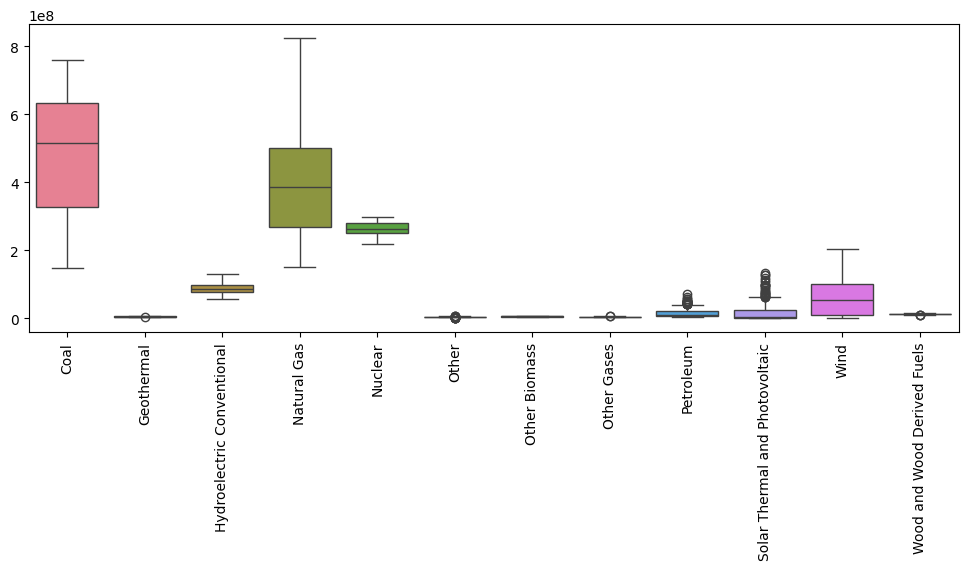

In [22]:
#chekc if we have outliers
import seaborn as sns

fig,ax = plt.subplots(1,1,figsize=(12,4))
ax = sns.boxplot(SERIES,ax=ax)
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)

#### Exploratory Analysis

Have any generation sources maintained, increased, or decreased their output levels consistently throughout the 2001-2025 period?

(-50000000.0, 1100000000.0)

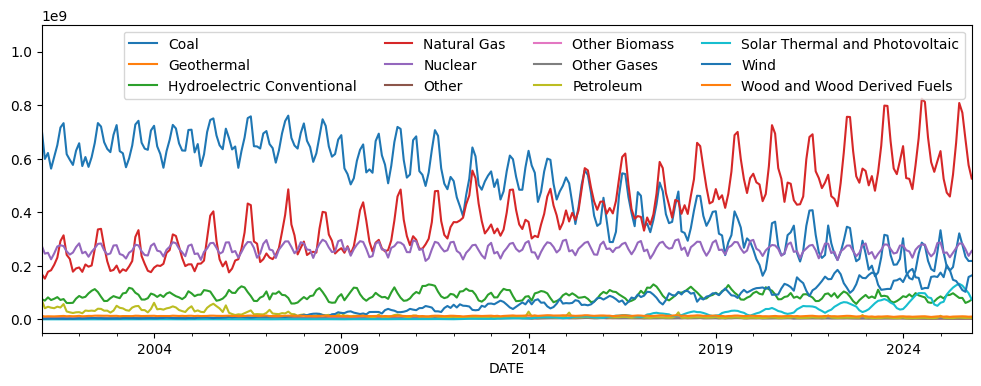

In [26]:
#Series
ax = SERIES.plot(figsize=(12,4))
ax.legend(loc="best",ncols=4)
ax.set_ylim([-0.5e8,11e8])

Some series are seasonal and other have trend and season.However this graphic is no clear to visualize them each one.

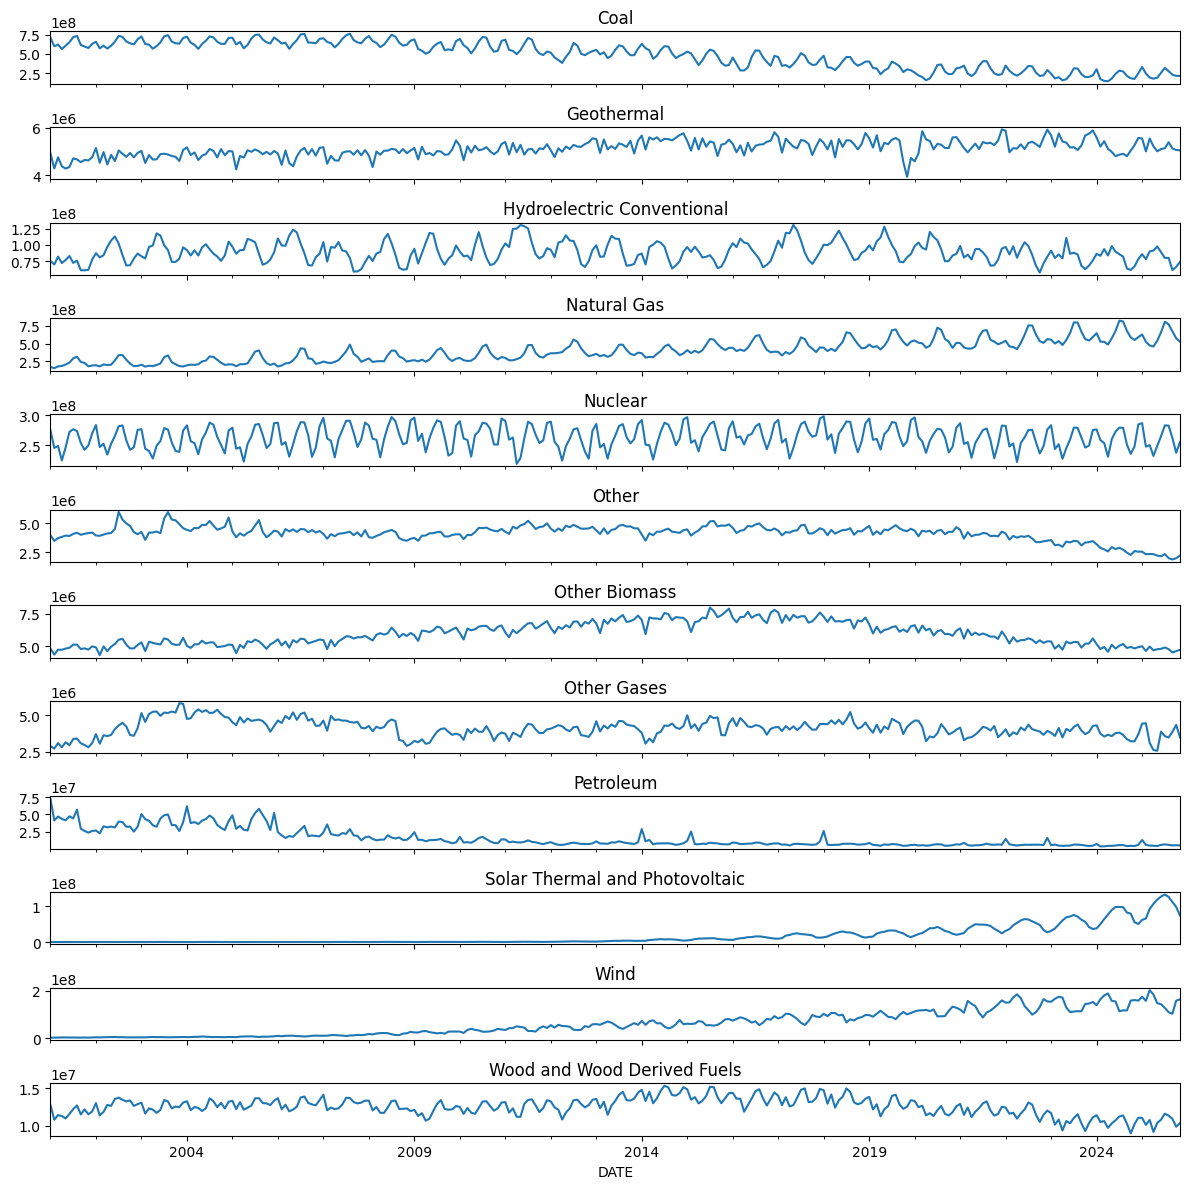

In [42]:
N = SERIES.shape[1] #numnber of series time
COLS = SERIES.columns

fig,ax = plt.subplots(N,1,figsize=(12,12),sharex=True)

for i,col in enumerate(COLS):
    SERIES[col].plot(ax=ax[i])
    ax[i].set_title(col)

fig.tight_layout()

#### Observations

     1- The Hydroelectric and Nuclear energy have remained stable over and seasonal behavior.
     2- The Solar thermal and wind energy have been increasing since 2012 year
     3- The Coal and petroleum have been decreasing.

#### Correlation Analysis

We will print correlation matrices; the threshold value we will use will be 0.75 for the magnitudes.

In [44]:
%matplotlib inline

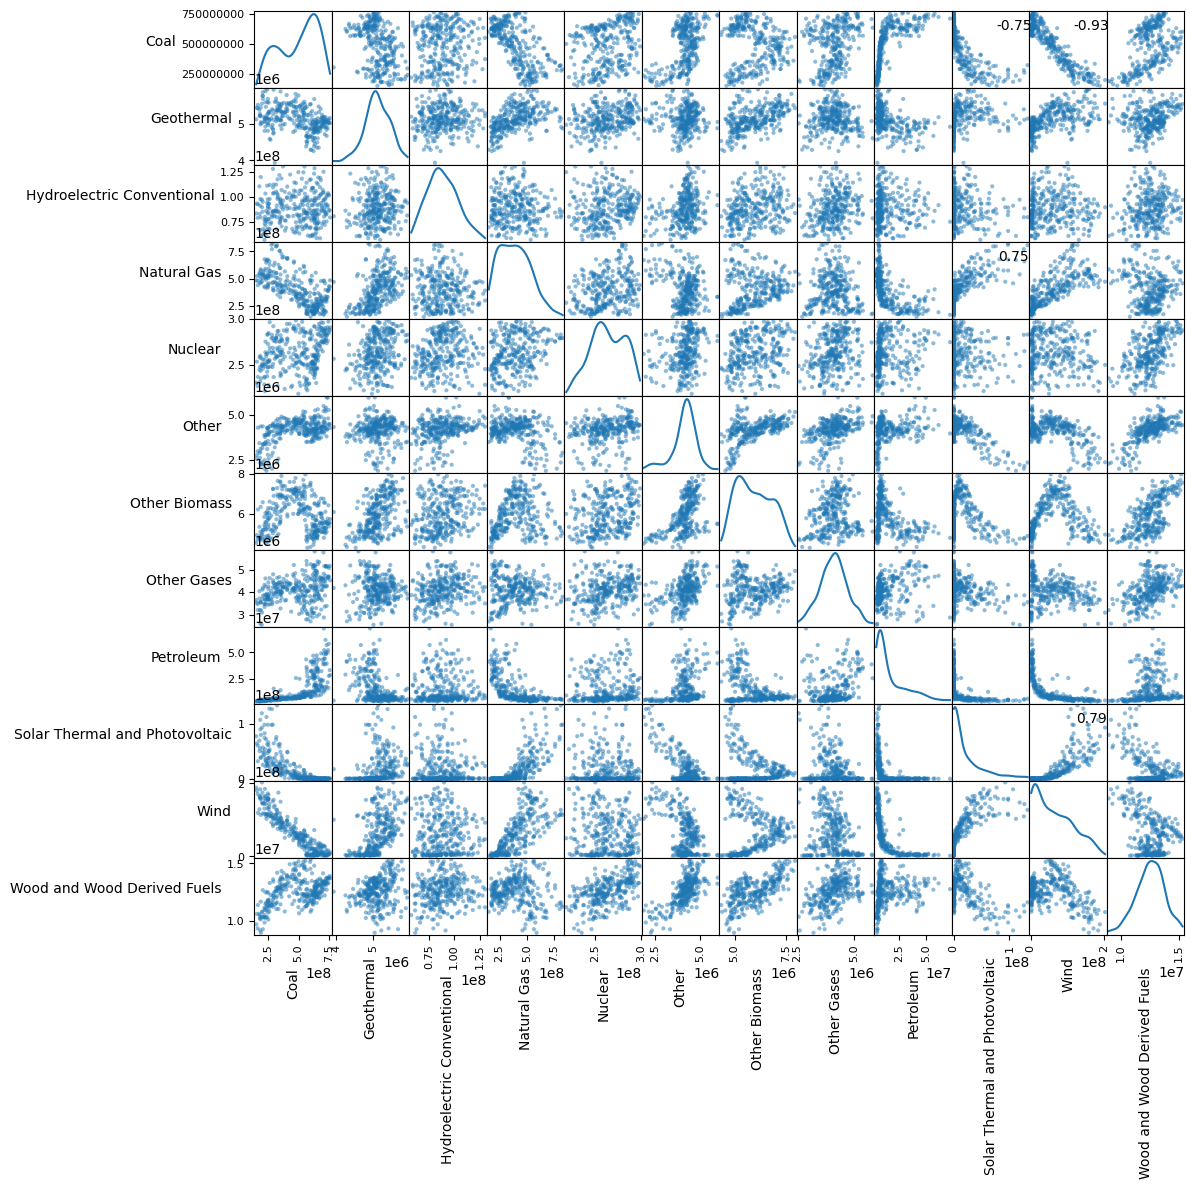

In [58]:
import numpy as np

ax = pd.plotting.scatter_matrix(SERIES,alpha=0.5,diagonal='kde',figsize=(12,12))

corr = SERIES.corr().to_numpy()

#add labels onluy for coeficients above diagonal and  0.75 treshold
for i,j in zip(*plt.np.triu_indices_from(ax,k=1)):
    if np.abs(corr[i,j]) >= 0.75:
        ax[i,j].annotate(f"{corr[i,j]:.2f}",(0.8,0.8),
                        xycoords="axes fraction",ha="center",va="center")


for axis in ax.flatten():
    axis.xaxis.label.set_rotation(90)
    axis.yaxis.label.set_rotation(0)
    axis.yaxis.label.set_ha('right')


##### Observations About Correlations

1. Correlation Analysis

Strong Positive Correlations (>0.75): A strong, positive relationship exists between the growth of renewables and natural gas.
* Solar (Thermal & PV) and Wind: 0.84
* Natural Gas and Solar (Thermal & PV): 0.78
* Natural Gas and Wind: 0.73

Strong Negative Correlations (>0.75): The expansion of renewables and gas coincides with a pronounced decline in coal-based generation.
* Coal and Wind: -0.93
* Coal and Solar (Thermal & PV): [Nota: Es crucial incluir el valor numérico aquí para que el dato sea completo. Ej: -0.89]

2. Interpretation of Trends
The observed correlation matrix reveals two defining trends for the 2001-2025 period:

Concurrent Growth: The strong positive correlations indicate a synchronized increase in the utilization of solar (thermal and photovoltaic), wind, and natural gas generation sources.

Energy Transition Signal: The strong negative correlations, particularly between coal and renewables, demonstrate a clear displacement. Coal-based generation has decreased substantially, largely in favor of solar and wind energy sources.

##### Seasonal Analysis

In [63]:
from statsmodels.tsa.seasonal import STL

def seasonal_graphic(df,col,seasonal=False):
    #create a copy to avoid modify the original dataset
    df_c = df.copy()

    df_c['año'] = df_c.index.year
    df_c['mes'] = df_c.index.month

    if seasonal:
        #get seasonal component
        df_stl = STL(df_c[col],seasonal=13).fit()

        col += "_seas"
        df_c[col] = df_stl.seasonal.to_frame(col)

    df_pivot = df_c.pivot(index="mes",columns="año",values=col)

    #For each year graphic month to month
    ax= df_pivot.plot(figsize=(12,4))
    plt.title(f"Seasonal Graphic: {col}")
    plt.xlabel("Mes")
    plt.ylabel("Mwh")

    plt.legend(title="Año",loc="best",ncols=9)
    

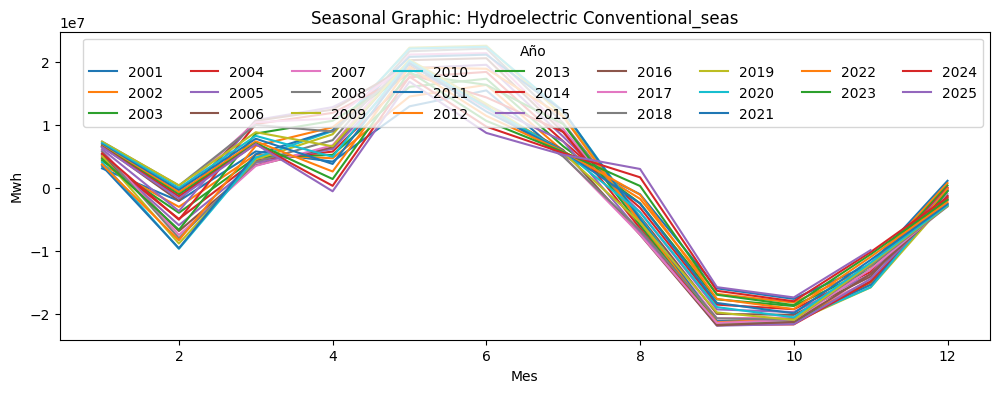

In [66]:
seasonal_graphic(SERIES,"Hydroelectric Conventional",seasonal=True)

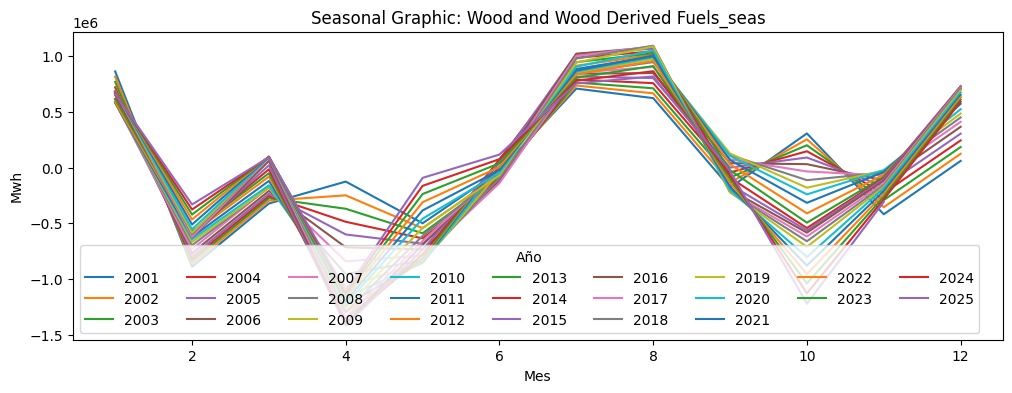

In [68]:
seasonal_graphic(SERIES,"Wood and Wood Derived Fuels",seasonal=True)

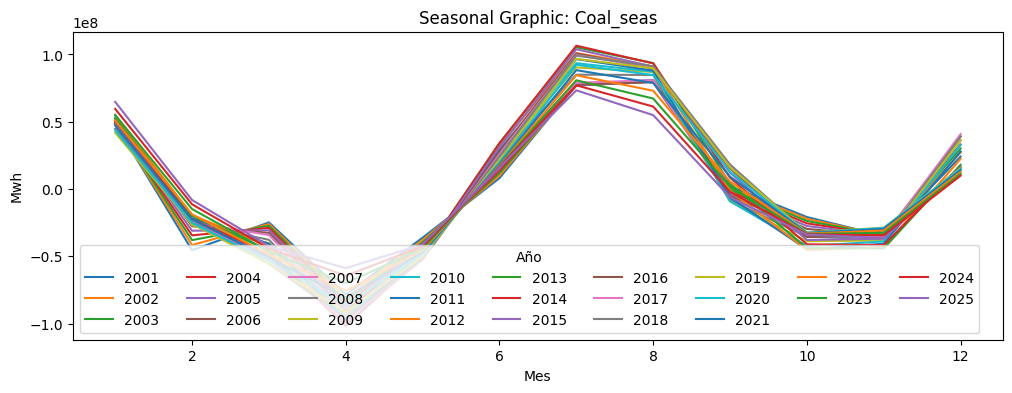

In [69]:
seasonal_graphic(SERIES,"Coal",seasonal=True)

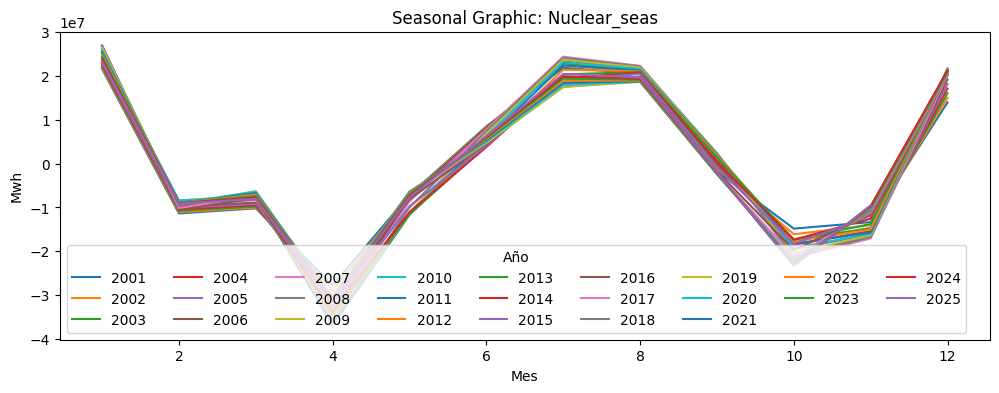

In [70]:
seasonal_graphic(SERIES,"Nuclear",seasonal=True)

#### Percentage of participation in generation into Mwh 
 
In this case, the idea is to see which sources show a tendency to increase or decrease their percentage of participation into Mwh generated

(-50000000.0, 1100000000.0)

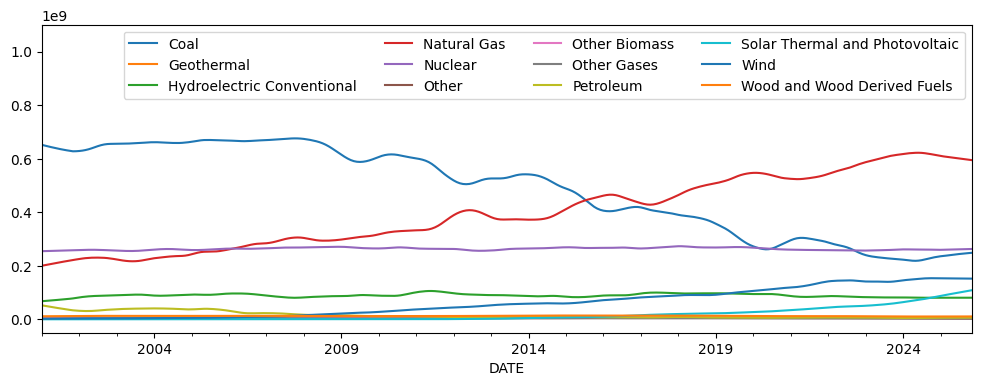

In [96]:
TRENDS = pd.DataFrame(index=SERIES.index)

for col in SERIES.columns:
    stl = STL(SERIES[col],seasonal=13).fit()

    TRENDS[col] = stl.trend

ax = TRENDS.plot(figsize=(12,4))
ax.legend(loc='best',ncols=4)
ax.set_ylim(-0.5e8,11e8)  

 

C:\Users\sgfar\AppData\Local\Temp\ipykernel_16020\3728031868.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  TRENDS_Y = TRENDS.resample('Y').sum()


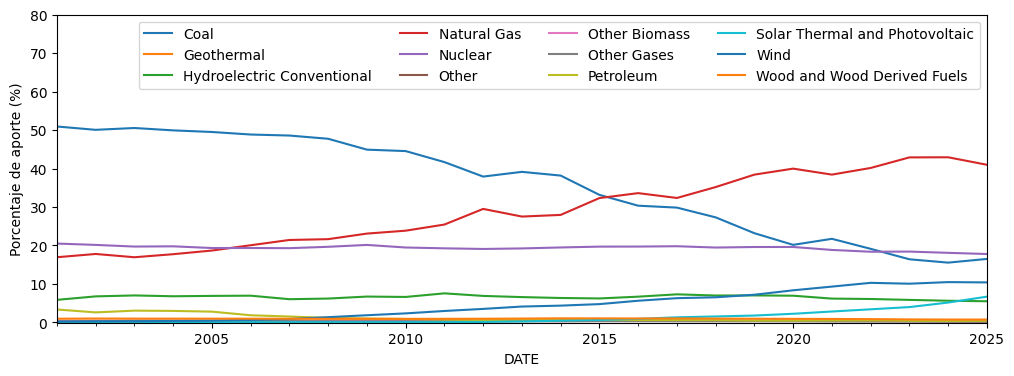

In [97]:
# Resample trend with annual frequency
TRENDS_Y = TRENDS.resample('Y').sum()

# Calcular porcentajes de aporte de cada tipo de generación por cada año
tot_anuales = TRENDS_Y.sum(axis=1)
TRENDS_PCTJ = 100*TRENDS_Y.div(tot_anuales, axis=0)

ax=TRENDS_PCTJ.plot(figsize=(12,4));
ax.legend(loc='best', ncols=4)
ax.set_ylim([-0.1, 80]);
ax.set_ylabel('Porcentaje de aporte (%)');


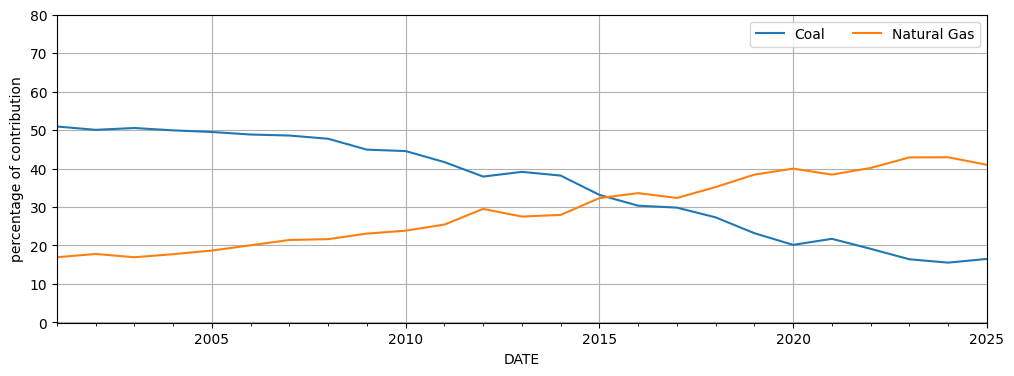

In [98]:
# Focus on "Coal" y "Natural Gas"
COLS = ['Coal', 'Natural Gas']

ax=TRENDS_PCTJ[COLS].plot(figsize=(12,4));
ax.legend(loc='best', ncols=4)
ax.set_ylim([-0.1, 80]);
ax.set_ylabel('percentage of contribution')
ax.grid()

#### Observations
 This shift is quantitatively underscored by the dramatic change in the generation mix. Coal-based power has undergone a steep decline, falling from a  50% share of total generation in 2001 to approximately 16% in 2025. 

 Conversely, natural gas generation has expanded significantly, increasing its share from 18% to 44% over the same period.

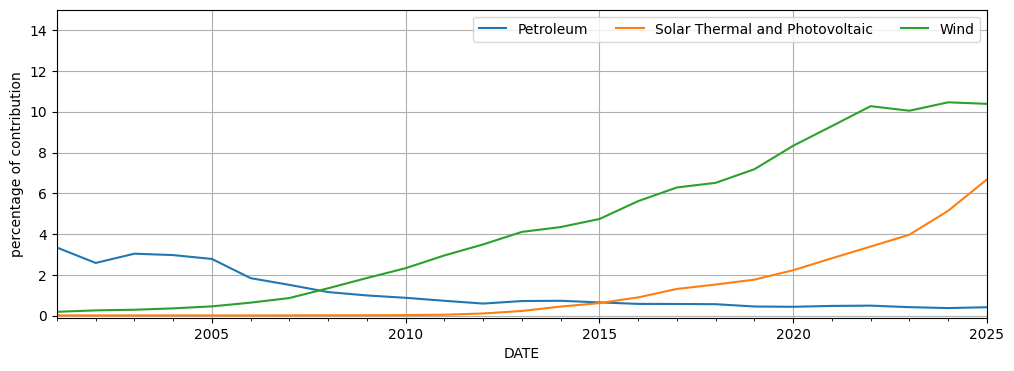

In [100]:
COLS = ['Petroleum', 'Solar Thermal and Photovoltaic', 'Wind']

ax=TRENDS_PCTJ[COLS].plot(figsize=(12,4));
ax.legend(loc='best', ncols=4)
ax.set_ylim([-0.1, 15]);
ax.set_ylabel('percentage of contribution')
ax.grid()

#### Observations

This structural shift away from carbon-intensive sources is further illustrated by the trends in oil and renewables. The use of oil for power generation has diminished significantly, with its share declining from 3.5% in 2001 to less than 1% in 2025. Meanwhile, renewable sources have seen remarkable growth from a negligible base: solar (thermal and photovoltaic) increased from under 0.5% to just over 4%, and wind power surged from under 0.5% to approximately 10% of the generation mix by 2025.

### Conclusions

At this point, we have used various tools to conduct the exploratory data analysis. The final step is to synthesize all our observations to answer the original question:

Have any generation sources maintained stable, increased, or decreased their output levels during the 2001-2025 period?

Based on the analysis performed, the key findings are as follows:

The correlation analysis suggests that the rise in solar (thermal and photovoltaic) and wind generation is associated with an increase in natural gas usage and a significant decline in coal-based generation.

Several generation sources have exhibited clear trends: some have remained stable (e.g., hydroelectric and nuclear), while others show a marked increase (solar/PV, wind) or decrease (coal and oil) during the 2001-2025 period.

In summary, the analysis reveals a clear transition toward cleaner and more sustainable energy sources, such as solar, wind, and natural gas, while dependence on more polluting sources like coal and oil has declined sharply. Furthermore, hydroelectric and nuclear sources have provided a stable generation base throughout the period under study.